# Black Swan - Modelare si Comparatie Algoritmi
**Scop:** Antrenam si comparam 4 algoritmi pentru clasificarea tiparului de recuperare  
**Algoritmi:** Naive Bayes, K-Nearest Neighbors, Random Forest, XGBoost

## 1. Import si Incarcare Date

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.naive_bayes      import GaussianNB
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

os.makedirs('plots', exist_ok=True)

dataset = pd.read_csv('black_swan_dataset.csv', index_col=0, parse_dates=True)

feature_cols = [
    'Return_1d', 'Return_5d', 'Dist_MA50', 'Dist_MA200',
    'Dist_52w_High', 'VIX', 'VIX_Change', 'Realized_Vol_10d',
    'Volume_Ratio', 'Consec_Down', 'RSI'
]

print('Librarii incarcate cu succes.')
print('Dataset shape:', dataset.shape)
print('Clase:', dataset['label'].unique())

Librarii incarcate cu succes.
Dataset shape: (2381, 19)
Clase: ['L-shape' 'U-shape' 'V-shape']


## 2. Reconstructie Train / Test Split

In [15]:
TRAIN_EVENTS = [
    'Global Financial Crisis', 'European Debt Crisis',
    'Taper Tantrum', 'China Devaluation', '9/11', 'Flash Crash'
]
TEST_EVENTS = [
    'Fed Rate Hikes 2022', 'COVID Crash', 'Liberation Day Tariffs'
]

dotcom_all   = dataset[dataset['event_name'] == 'Dotcom Crash']
dotcom_train = dotcom_all.iloc[:-200]
dotcom_test  = dotcom_all.iloc[-200:]

train_df = pd.concat([dotcom_train, dataset[dataset['event_name'].isin(TRAIN_EVENTS)]])
test_df  = pd.concat([dotcom_test,  dataset[dataset['event_name'].isin(TEST_EVENTS)]])

train_df = train_df.dropna(subset=feature_cols)
test_df  = test_df.dropna(subset=feature_cols)

X_train_raw = train_df[feature_cols]
y_train     = train_df['label']
X_test_raw  = test_df[feature_cols]
y_test      = test_df['label']

print('Train:', len(X_train_raw), 'zile | Test:', len(X_test_raw), 'zile')
print('\nDistributie train:')
print(y_train.value_counts())
print('\nDistributie test:')
print(y_test.value_counts())

Train: 1646 zile | Test: 735 zile

Distributie train:
label
V-shape    758
L-shape    511
U-shape    377
Name: count, dtype: int64

Distributie test:
label
V-shape    284
U-shape    251
L-shape    200
Name: count, dtype: int64


## 3. Scalare Features

KNN si Naive Bayes sunt sensibile la scala. Fara scalare, VIX (valori 15-80) ar domina  
fata de Return_1d (valori 0.01-0.05). Aplicam StandardScaler: fit doar pe train, transform pe ambele.

In [16]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Scalare completata.')
print('Mapare clase pentru XGBoost:', mapping)

Scalare completata.
Mapare clase pentru XGBoost: {'L-shape': np.int64(0), 'U-shape': np.int64(1), 'V-shape': np.int64(2)}


## 4. Antrenare Algoritmi

In [17]:
models = {
    'Naive Bayes'   : GaussianNB(),
    'KNN'           : KNeighborsClassifier(n_neighbors=15, metric='euclidean'),
    'Random Forest' : RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost'       : XGBClassifier(
                          n_estimators=200, max_depth=4, learning_rate=0.05,
                          eval_metric='mlogloss', random_state=42
                      )
}

results = {}

for name, model in models.items():
    y_tr = y_train_enc if name == 'XGBoost' else y_train

    model.fit(X_train, y_tr)
    y_pred_raw = model.predict(X_test)

    y_pred   = le.inverse_transform(y_pred_raw) if name == 'XGBoost' else y_pred_raw
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': accuracy
    }

    print(name.ljust(20), 'Accuracy:', round(accuracy, 3))

print('\nAntrenare completa.')

Naive Bayes          Accuracy: 0.434
KNN                  Accuracy: 0.522
Random Forest        Accuracy: 0.415
XGBoost              Accuracy: 0.431

Antrenare completa.


## 5. Classification Report Detaliat

In [18]:
separator = '=' * 50

for name, res in results.items():
    print(separator)
    print(name)
    print(separator)
    print(classification_report(y_test, res['y_pred']))
    print()

Naive Bayes
              precision    recall  f1-score   support

     L-shape       0.33      0.49      0.39       200
     U-shape       0.19      0.12      0.15       251
     V-shape       0.67      0.67      0.67       284

    accuracy                           0.43       735
   macro avg       0.40      0.43      0.41       735
weighted avg       0.42      0.43      0.42       735


KNN
              precision    recall  f1-score   support

     L-shape       0.41      0.68      0.51       200
     U-shape       0.39      0.16      0.23       251
     V-shape       0.69      0.74      0.71       284

    accuracy                           0.52       735
   macro avg       0.50      0.52      0.48       735
weighted avg       0.51      0.52      0.49       735


Random Forest
              precision    recall  f1-score   support

     L-shape       0.32      0.62      0.43       200
     U-shape       0.00      0.00      0.00       251
     V-shape       0.60      0.63      0.62

## 6. Confusion Matrices

### Cum se citeste

**Axa Y (verticala) = ce a fost in realitate** (label-ul adevarat)  
**Axa X (orizontala) = ce a prezis modelul**

```
                  Prezis L    Prezis U    Prezis V
Real L-shape  [     85    |     10    |      5   ]  <- 85 L-shape ghicite corect
Real U-shape  [     20    |    180    |     51   ]  <- 20 U-shape confundate cu L
Real V-shape  [      2    |     15    |    267   ]  <- cel mai bine recunoscut
```

**Diagonala principala = predictii corecte.** Vrem numere mari pe diagonala.  
**Orice valoare in afara diagonalei = eroare.** Cu cat e mai departe de diagonala,  
cu atat confuzia e mai grava (ex: L confundat cu V e mai rau decat L confundat cu U).

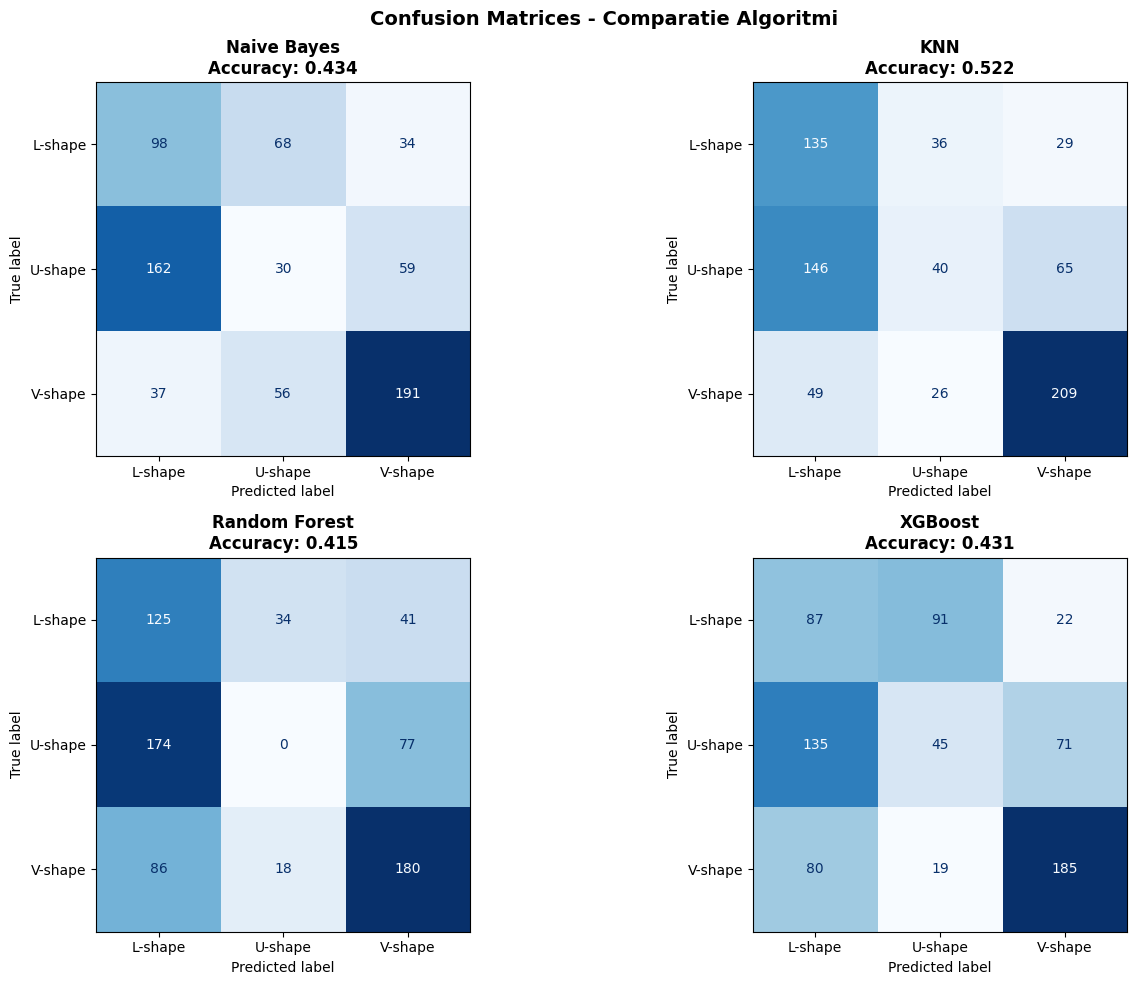

Salvat: plots/confusion_matrices.png


In [19]:
classes = sorted(y_test.unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'], labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        name + '\nAccuracy: ' + str(round(res['accuracy'], 3)),
        fontsize=12, fontweight='bold'
    )

plt.suptitle('Confusion Matrices - Comparatie Algoritmi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/confusion_matrices.png')

## 7. Comparatie Finala - Accuracy Bar Chart

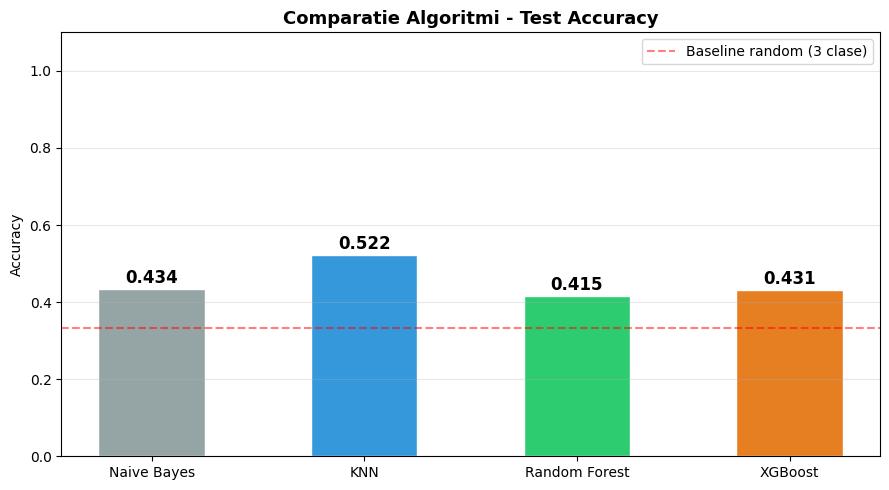

Salvat: plots/accuracy_comparison.png


In [20]:
names      = list(results.keys())
accuracies = [results[n]['accuracy'] for n in names]
bar_colors = ['#95a5a6', '#3498db', '#2ecc71', '#e67e22']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, accuracies, color=bar_colors, edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        str(round(acc, 3)),
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparatie Algoritmi - Test Accuracy', fontsize=13, fontweight='bold')
ax.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Baseline random (3 clase)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/accuracy_comparison.png')

## 8. Feature Importance (Random Forest si XGBoost)

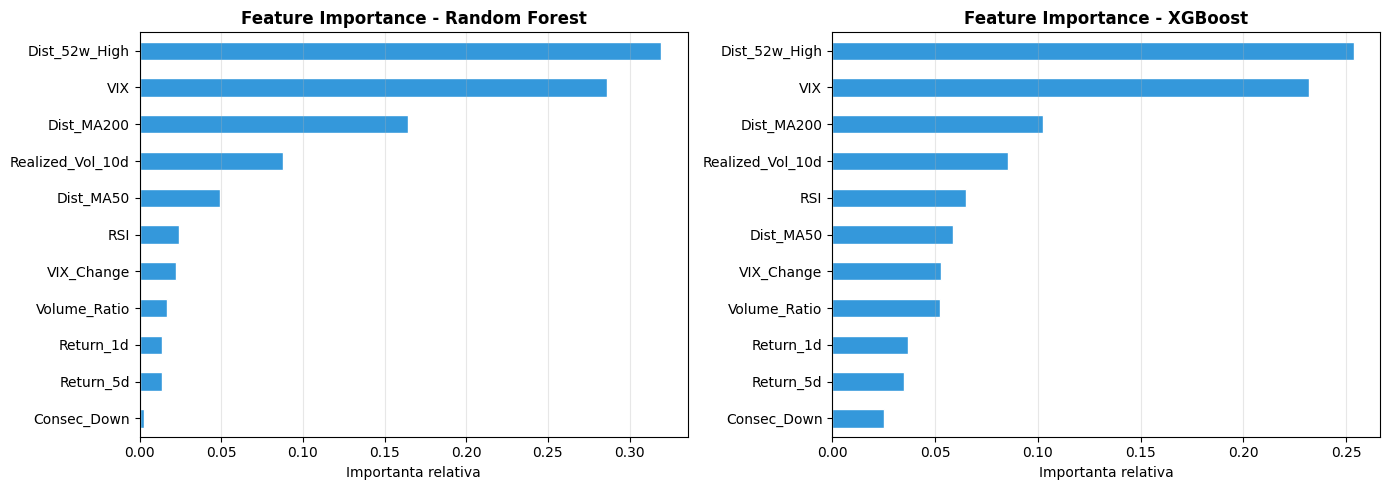

Salvat: plots/feature_importance.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model = results[model_name]['model']
    importances = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True)

    importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title('Feature Importance - ' + model_name, fontweight='bold')
    ax.set_xlabel('Importanta relativa')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/feature_importance.png')

## 9. Probabilitati per Eveniment de Test

Cum evolueaza probabilitatile de V/U/L-shape zi de zi pe durata fiecarui eveniment de test.

Cel mai bun model: KNN


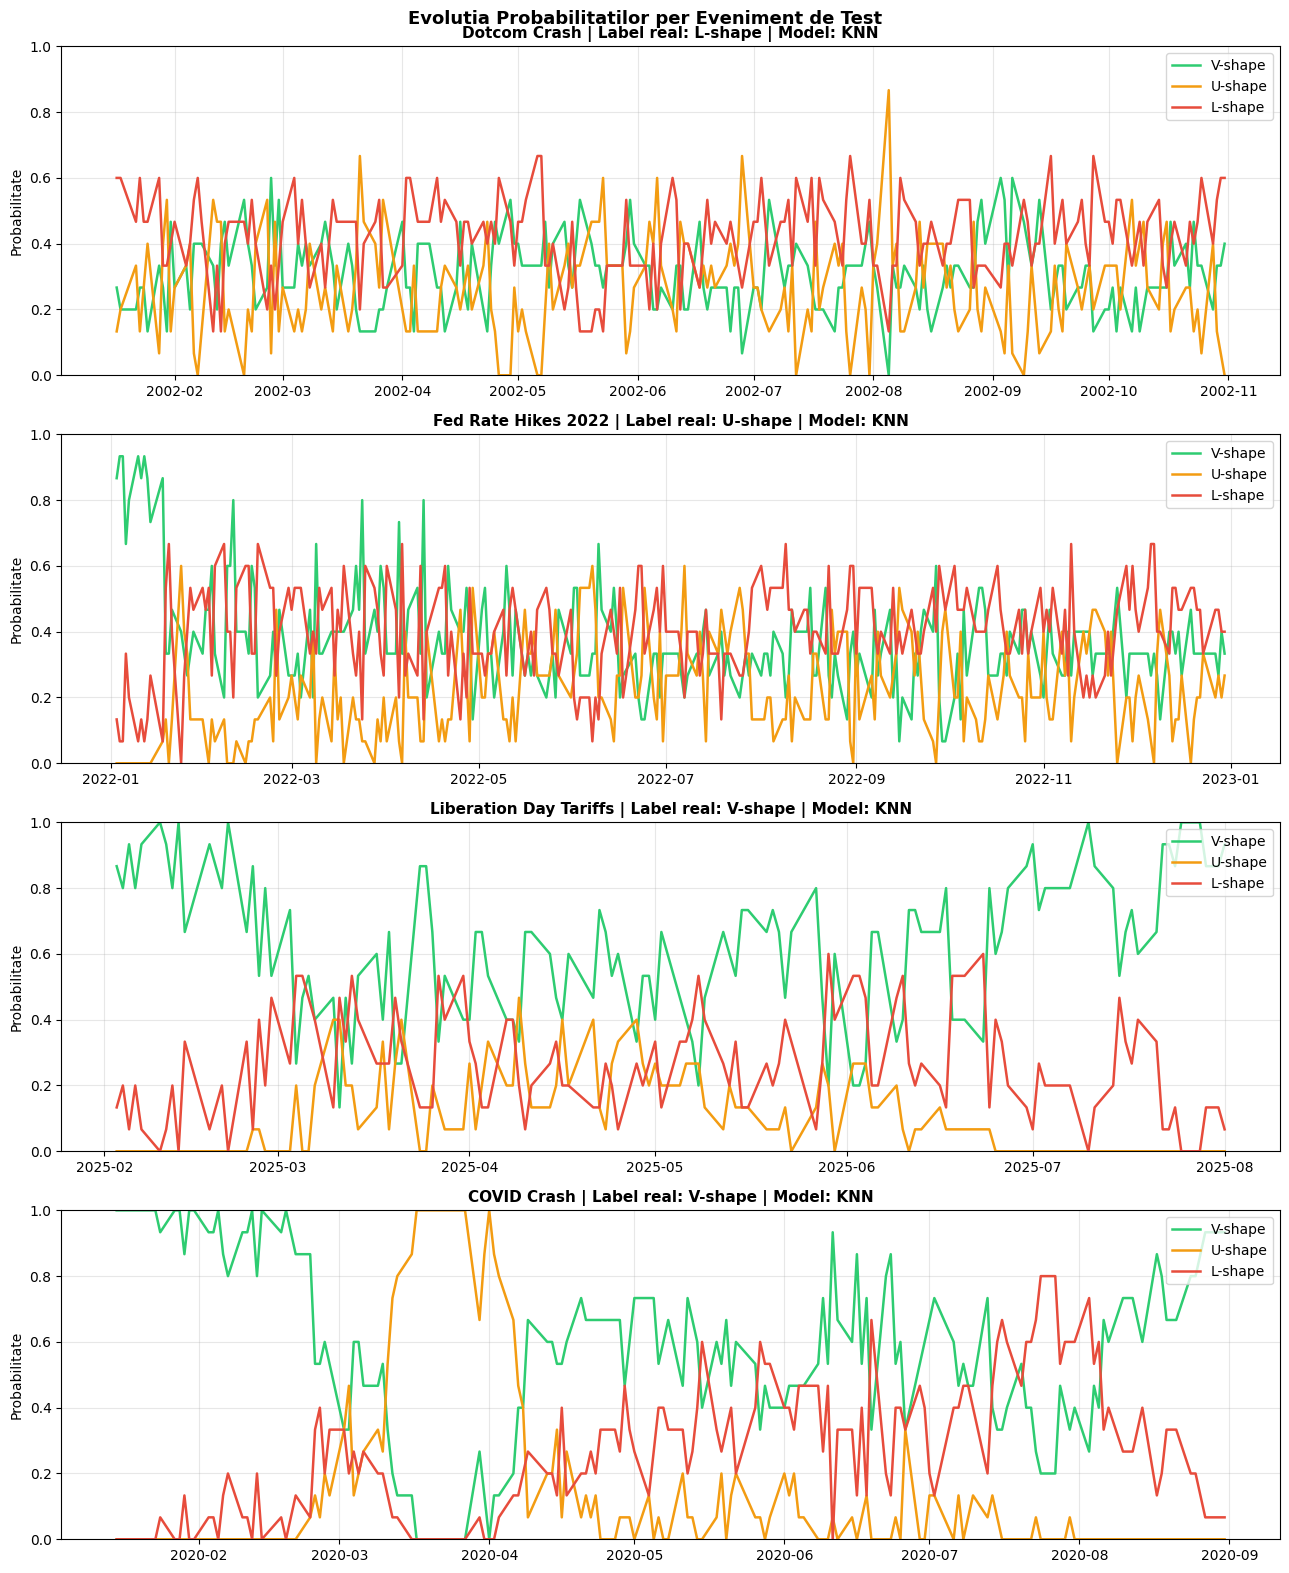

Salvat: plots/probabilities_per_event.png


In [22]:
best_model_name = max(results, key=lambda n: results[n]['accuracy'])
best_model      = results[best_model_name]['model']
print('Cel mai bun model:', best_model_name)

proba_matrix = best_model.predict_proba(X_test)
class_labels = le.classes_ if best_model_name == 'XGBoost' else best_model.classes_

proba_df = pd.DataFrame(proba_matrix, columns=class_labels, index=test_df.index)
proba_df['event_name'] = test_df['event_name'].values
proba_df['true_label'] = test_df['label'].values

test_event_names = test_df['event_name'].unique()
colors_map = {'V-shape': '#2ecc71', 'U-shape': '#f39c12', 'L-shape': '#e74c3c'}

fig, axes = plt.subplots(len(test_event_names), 1, figsize=(13, 4 * len(test_event_names)))

if len(test_event_names) == 1:
    axes = [axes]

for ax, event in zip(axes, test_event_names):
    ev_proba = proba_df[proba_df['event_name'] == event]
    true_lbl = ev_proba['true_label'].iloc[0]

    for cls, color in colors_map.items():
        if cls in ev_proba.columns:
            ax.plot(ev_proba.index, ev_proba[cls], label=cls, color=color, linewidth=1.8)

    ax.set_title(
        event + ' | Label real: ' + true_lbl + ' | Model: ' + best_model_name,
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Probabilitate')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolutia Probabilitatilor per Eveniment de Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/probabilities_per_event.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/probabilities_per_event.png')

## 10. Rezumat Final

In [23]:
separator = '=' * 45
print('REZUMAT FINAL')
print(separator)

summary = pd.DataFrame({
    'Model'   : list(results.keys()),
    'Accuracy': [round(results[n]['accuracy'], 4) for n in results]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

summary.index += 1
print(summary.to_string())

baseline = round(1/3, 4)
best_acc = round(results[best_model_name]['accuracy'], 4)

print('\nBaseline (random pe 3 clase):', baseline)
print('Cel mai bun model:', best_model_name, '(' + str(best_acc) + ')')
print('Imbunatatire vs baseline: +' + str(round(best_acc - baseline, 4)))
print('\nImagini salvate in folderul plots/')

REZUMAT FINAL
           Model  Accuracy
1            KNN    0.5224
2    Naive Bayes    0.4340
3        XGBoost    0.4313
4  Random Forest    0.4150

Baseline (random pe 3 clase): 0.3333
Cel mai bun model: KNN (0.5224)
Imbunatatire vs baseline: +0.1891

Imagini salvate in folderul plots/
